In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving sales_dataset.csv to sales_dataset.csv


In [3]:
df = pd.read_csv('sales_dataset.csv', low_memory=False)

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Column1             128949 non-null  object 
 1   Date                128949 non-null  object 
 2   Status              128949 non-null  object 
 3   Fulfilment          128949 non-null  object 
 4   Sales Channel       128949 non-null  object 
 5   ship-service-level  128949 non-null  object 
 6   Style               128949 non-null  object 
 7   SKU                 128949 non-null  object 
 8   Category            128949 non-null  object 
 9   Size                128949 non-null  object 
 10  ASIN                128949 non-null  object 
 11  Courier Status      122078 non-null  object 
 12  Qty                 128949 non-null  int64  
 13  currency            121155 non-null  object 
 14  Amount              121155 non-null  float64
 15  ship-city           128916 non-nul

In [5]:
print(df.shape)

(128949, 23)


In [6]:
# This line prints the count of null values for each column.
print(df.isnull().sum())

Column1                   0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6871
Qty                       0
currency               7794
Amount                 7794
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49142
B2B                       0
fulfilled-by          89679
Unnamed: 22           49041
dtype: int64


In [7]:
# Unnamed: 22 contains mostly empty values.It does not add useful information.
df.drop(columns =['Unnamed: 22'], inplace= True)

In [8]:
# Missing courier status values are replaced with Unknown.
df['Courier Status']=df['Courier Status'].fillna("Unknown")

In [9]:
# Almost all transactions are in INR, so missing values are replaced with INR.
df['currency'] = df['currency'].fillna("INR")

In [10]:
# Missing sales amounts are replaced with the median value because it handles outliers better than mean.
df['Amount'] = df['Amount'].fillna(df['Amount'].median())

In [11]:
# Rows without promotions are labeled as No Promotion
df['promotion-ids'] = df['promotion-ids'].fillna("No Promotion")

In [12]:
# Missing fulfillment values are replaced for consistency.
df['fulfilled-by'] = df['fulfilled-by'].fillna("Not Specified")

In [13]:
# This checks how many duplicate rows exist
print(df.duplicated().sum())

6


In [14]:
# Removes repeated rows from the dataset.
df.drop_duplicates(inplace=True)

In [15]:
# Converts the Date column into proper datetime format.
df['Date'] = pd.to_datetime(df['Date'],format = "mixed")

In [16]:
# Makes text formatting consistent.
df['Category'] = df['Category'].str.title()
df['ship-city'] = df['ship-city'].str.title()
df['ship-state'] = df['ship-state'].str.title()

In [17]:
# Converts postal codes into integer datatype.
df['ship-postal-code'] = df['ship-postal-code'].astype("Int64")

In [18]:
# Ensures the dataset is now clean and ready for analysis.
print(df.info())
print(df.isnull().sum())

# # It was observed after cleaning data only 33 data are missing in ship-city, ship-state, ship-postal-code, ship-country. so i am editing it(Replacing the values)

<class 'pandas.core.frame.DataFrame'>
Index: 128943 entries, 0 to 128948
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Column1             128943 non-null  object        
 1   Date                128943 non-null  datetime64[ns]
 2   Status              128943 non-null  object        
 3   Fulfilment          128943 non-null  object        
 4   Sales Channel       128943 non-null  object        
 5   ship-service-level  128943 non-null  object        
 6   Style               128943 non-null  object        
 7   SKU                 128943 non-null  object        
 8   Category            128943 non-null  object        
 9   Size                128943 non-null  object        
 10  ASIN                128943 non-null  object        
 11  Courier Status      128943 non-null  object        
 12  Qty                 128943 non-null  int64         
 13  currency            128943 non-nul

In [19]:
# Exports the cleaned dataset as a new CSV file.
df.to_csv('Cleaned_Sales_Dataset.csv', index = False)

In [20]:
df.to_csv('Cleaned_Sales_Dataset.csv', index = False)
from google.colab import files
files.download('Cleaned_Sales_Dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
df['ship-city'] = df['ship-city'].fillna("Not Specified")
df['ship-state'] = df['ship-state'].fillna("Not Specified")
df['ship-postal-code'] = df['ship-postal-code'].fillna(df['ship-postal-code'].median())
df['ship-country'] = df['ship-country'].fillna("In")

In [22]:
# Rename the column from column1 to Order_Id
df.rename(columns={'Column1': 'Order_Id'}, inplace=True)

# EDA: Exploratory Data Analysis

# **FINANCIAL PERFORMANCE ANALYSIS**

In [23]:
Total_Revenue = df['Amount'].sum()
print(Total_Revenue)

83286092.94


 **Total Revenue**:
**83286092.94**

In [24]:
print(df[['Qty', 'Amount']].describe())

                 Qty         Amount
count  128943.000000  128943.000000
mean        0.904648     645.914031
std         0.314758     272.785604
min         0.000000       0.000000
25%         1.000000     459.000000
50%         1.000000     605.000000
75%         1.000000     771.000000
max        15.000000    5584.000000


 **Total Revenue Growth Over Time.**

In [25]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

In [26]:
# This section tracks how revenue changes daily over time.
Rev_growth = df.groupby('Date')['Amount'].sum()
rev_pct_change = Rev_growth.pct_change()*100
comparison_df = pd.concat([Rev_growth, rev_pct_change], axis=1)
comparison_df.columns = ['Rev_growth', 'Percentage Change']
comparison_df.columns = ['Rev_growth', 'Percentage Change']
print(comparison_df)

            Rev_growth  Percentage Change
Date                                     
2022-03-31   107128.85                NaN
2022-04-01   930818.60         768.877618
2022-04-02   972996.53           4.531273
2022-04-03  1071658.38          10.140000
2022-04-04   937114.17         -12.554767
...                ...                ...
2022-06-25   691744.58           3.482653
2022-06-26   806280.02          16.557476
2022-06-27   748004.67          -7.227681
2022-06-28   818065.53           9.366367
2022-06-29   429075.76         -47.549952

[91 rows x 2 columns]


**Monthly Revenue Analysis**

In [27]:
Monthly_Revenue_Analysis = df.groupby('Month')['Amount'].sum().sort_values(ascending = False)
print(Monthly_Revenue_Analysis)


Month
April    30646525.96
May      27735050.75
June     24797387.38
March      107128.85
Name: Amount, dtype: float64


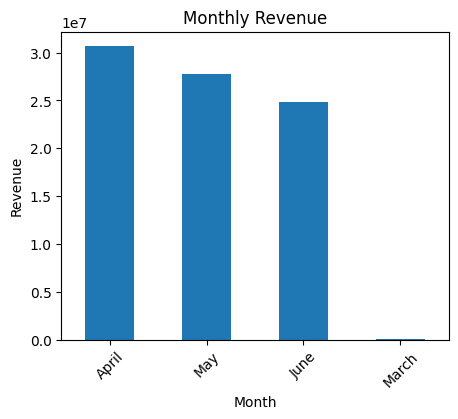

In [28]:
Monthly_Revenue_Analysis.plot(kind='bar', figsize=(5,4))
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

**Explanation**

The grouped monthly revenue analysis aggregates total sales amount month-wise.

**Business Insights**

April indicate strong customer demand.

June may require additional promotions.

# **Top 10 Seling Products**

In [29]:
top_products = df.groupby('SKU')['Amount'].sum().sort_values(ascending=False).head(10)

print(top_products)

SKU
JNE3797-KR-L       555436.77
J0230-SKD-M        547711.20
J0230-SKD-S        494457.14
JNE3797-KR-M       476070.16
JNE3797-KR-S       427872.57
JNE3797-KR-XL      349095.24
J0230-SKD-L        318926.95
JNE3797-KR-XS      318136.70
SET268-KR-NP-XL    292528.96
SET268-KR-NP-S     290020.48
Name: Amount, dtype: float64


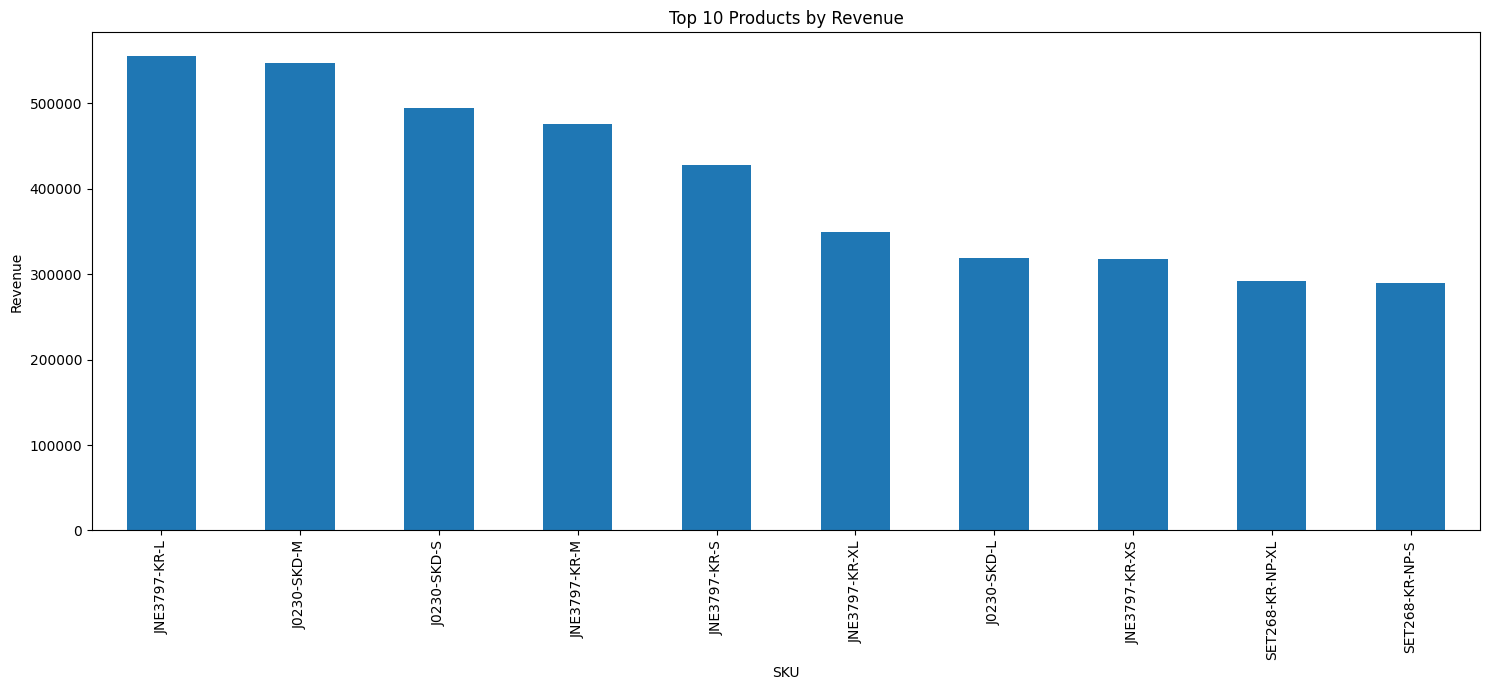

In [30]:
top_products.plot(kind='bar', figsize=(15,7))
plt.title('Top 10 Products by Revenue')
plt.xlabel('SKU')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Explanation**

Revenue is aggregated SKU-wise to identify star-performing products.

**Business Insights**

Top-performing products should receive higher marketing focus.

Weak products may require redesign or discount strategies.

Helps optimize inventory and product portfolio decisions.

# **Seasonal Sales Trends**

In [31]:
df['Month'] = df['Date'].dt.month_name()
df['Month_Number'] = df['Date'].dt.month

# Calculate monthly sales
seasonal_sales = (
    df.groupby(['Month_Number', 'Month'])['Amount'].sum().reset_index().sort_values('Month_Number'))

print(seasonal_sales)

   Month_Number  Month       Amount
0             3  March    107128.85
1             4  April  30646525.96
2             5    May  27735050.75
3             6   June  24797387.38


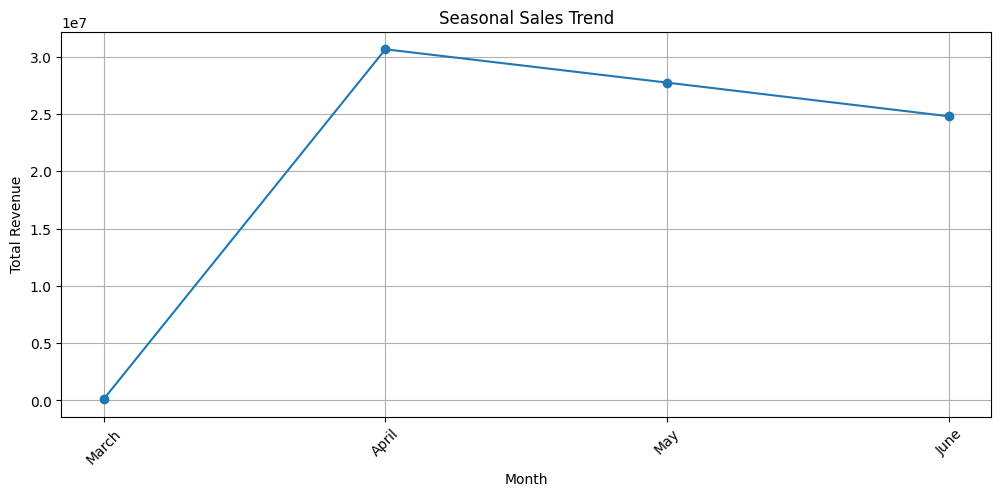

In [32]:
# Line chart for seasonal sales trend
plt.figure(figsize=(12,5))

plt.plot(
    seasonal_sales['Month'],
    seasonal_sales['Amount'],
    marker='o'
)

plt.title('Seasonal Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

 **Explanation**

Seasonal sales trend analysis helps identify peak periods.

**April** : High sales months

**March** : Low sales periods

**May & June** : Shows a slight steady decline but significantly higher than March

The Massive jump between March and April could indicate a successful marketing campaign, a seasonal product launch (like Spring/Summer collections),or a specific industry event.

# **The Average Order Value**

In [33]:
Tot_Revenue = df['Amount'].sum()
print("Total Revenue : ", Total_Revenue)
Total_orders = df['Order_Id'].nunique()
print("Total Orders : ",Total_orders)
AOL = Tot_Revenue / Total_orders
print("Average Order Value : ", AOL)


Total Revenue :  83286092.94
Total Orders :  120352
Average Order Value :  692.020846683063


**Explanation**

The Average Order Value (AOV) of ₹692 indicates moderate customer spending behavior. Customers spend approximately ₹692 per transaction, suggesting stable purchasing activity and healthy revenue generation opportunities for the business.”



**AOL Suggests** (About Customer Behavior)

Customers are willing to spend a reasonable amount.
Product pricing may be well-balanced.
The platform has stable purchasing activity.
Possible Opportunities

**The business can further increase AOV through**:

Combo offers
Product bundles
Cross-selling related items
Upselling premium products
Free shipping above certain order value

**Example**: Free shipping on orders above ₹999. This encourages customers to add more products.

# Financial Performance Analysis

**Key Findings:**

The total revenue stands at ₹83.29 Million.

April showed the highest monthly revenue, followed by May and June, with a notable low in March.

The Average Order Value (AOV) is ₹692, indicating moderate customer spending.

"Set" and "Kurta" are the highest revenue-generating product categories.

**Problematic Areas:**

There is a noticeable decline in monthly revenue from April to June, which warrants investigation.

The negligible sales in March suggest potential seasonal gaps or uncapitalized opportunities.

**Recommendations:**

**Revenue Growth:**
 Investigate the reasons behind the revenue decline in June to identify and mitigate underlying issues. Explore marketing strategies or seasonal product launches for the March period.

**AOV Enhancement:**

 Implement strategies such as combo offers, product bundles, upselling premium products, and free shipping thresholds (e.g., above ₹999) to encourage higher spending per transaction.

**Product Focus:**
Capitalize on the success of top-performing products (e.g., "Set" and "Kurta") through targeted marketing and inventory prioritization.

# **CUSTOMER INSIGHTS ANALYSIS**

**Top-Performing locations**

In [34]:
loc_sales = df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(10)

print(loc_sales)

ship-city
Bengaluru    7601234.80
Hyderabad    5920997.35
Mumbai       4481147.16
New Delhi    4172143.20
Chennai      3801818.94
Pune         2936571.79
Kolkata      1782476.99
Gurugram     1332939.78
Thane        1173821.35
Lucknow      1115928.10
Name: Amount, dtype: float64


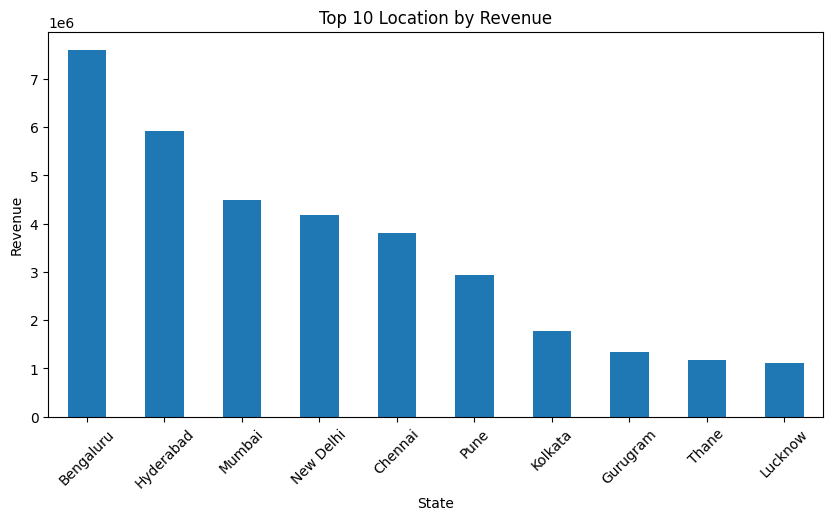

In [35]:
loc_sales.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Location by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

**Explanation**

Revenue is aggregated state-wise to identify strong-performing regions.

**Business Insights**

*   Bengaluru with high revenue have key target markets. Regional trends help   businesses optimize logistics and marketing.
*   Gurugram Thane and Lucknow may need awareness campaigns.






# **Top-performing locations based on sales volume**

In [36]:
location_sales = df.groupby('ship-city')['Amount'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Performing Locations:\n")
print(location_sales.head(10))


Top 10 Performing Locations:

ship-city
Bengaluru    7601234.80
Hyderabad    5920997.35
Mumbai       4481147.16
New Delhi    4172143.20
Chennai      3801818.94
Pune         2936571.79
Kolkata      1782476.99
Gurugram     1332939.78
Thane        1173821.35
Lucknow      1115928.10
Name: Amount, dtype: float64


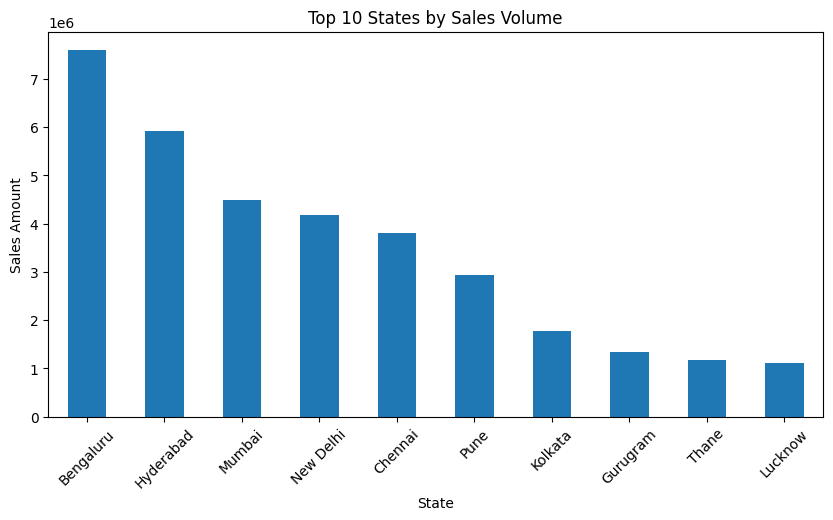

In [37]:
# Visualization
location_sales.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 States by Sales Volume')
plt.xlabel('State')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.show()

**Explanation**

**Bengaluru** has the highest sales and having strongest markets.

These top 10 states locations can be targeted for:

*   More advertising
*   Faster delivery services List item
*   Loyalty programs
*   Warehouse expansion

# **Order Cancellation Trends & Customer Retention**

**Cancellation Trend Analysis**

In [38]:
# Count order status
cancel_trend = df['Status'].value_counts()

print(cancel_trend)

# Cancellation percentage
cancelled_orders = df[df['Status'].str.contains('Cancelled', case=False, na=False)]

cancel_rate = (len(cancelled_orders) / len(df)) * 100

print("Cancellation Rate:", round(cancel_rate,2), "%")

Status
Shipped                          77764
Shipped - Delivered to Buyer     28771
Cancelled                        18338
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64
Cancellation Rate: 14.22 %


**Cancellation by State**

In [39]:
cancel_by_state = (cancelled_orders.groupby('ship-state').size().sort_values(ascending=False).head(10))
print(cancel_by_state)

ship-state
Maharashtra       2968
Karnataka         2246
Telangana         1631
Uttar Pradesh     1607
Tamil Nadu        1595
Kerala            1174
Delhi              909
Andhra Pradesh     892
West Bengal        885
Gujarat            591
dtype: int64


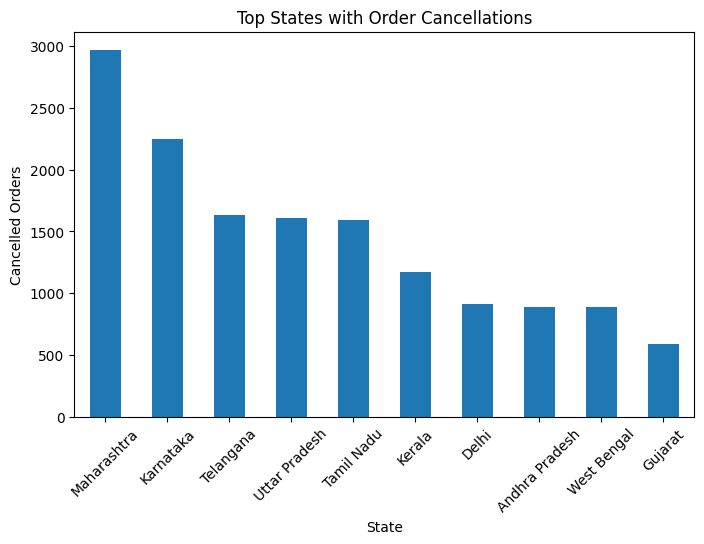

In [40]:
cancel_by_state.plot(kind='bar', figsize=(8,5))
plt.title('Top States with Order Cancellations')
plt.xlabel('State')
plt.ylabel('Cancelled Orders')
plt.xticks(rotation=45)
plt.show()

# **Customer Retention Analysis**

In [41]:
retention = (
    df.groupby('ship-city').agg(Orders=('Order_Id', 'count'),
        Revenue=('Amount', 'sum')
    ).sort_values(by='Orders', ascending=False))

print(retention.head(10))

           Orders     Revenue
ship-city                    
Bengaluru   11892  7601234.80
Hyderabad    9122  5920997.35
Mumbai       7120  4481147.16
New Delhi    6337  4172143.20
Chennai      6282  3801818.94
Pune         4615  2936571.79
Kolkata      2844  1782476.99
Gurugram     1953  1332939.78
Thane        1877  1173821.35
Lucknow      1627  1115928.10


**Explanation**:

**High cancellation rates indicates:**

*   Delivery issues
*   Product mismatch
*   Payment failures
*   Poor customer experience

**Cities with repeated high order counts indicate:**

Better customer loyalty

Higher retention potential

# **Differentiating B2B vs B2C Customer Behavior**

**Sales Comparison**

In [42]:
b2b_analysis = (
    df.groupby('B2B')
    .agg(
        Total_Sales=('Amount', 'sum'),
        Total_Orders=('Order_Id', 'count'),
        Avg_Order_Value=('Amount', 'mean'),
        Total_Quantity=('Qty', 'sum')))

print(b2b_analysis)

       Total_Sales  Total_Orders  Avg_Order_Value  Total_Quantity
B2B                                                              
False  82677932.15        128072       645.558218          115807
True     608160.79           871       698.232824             841


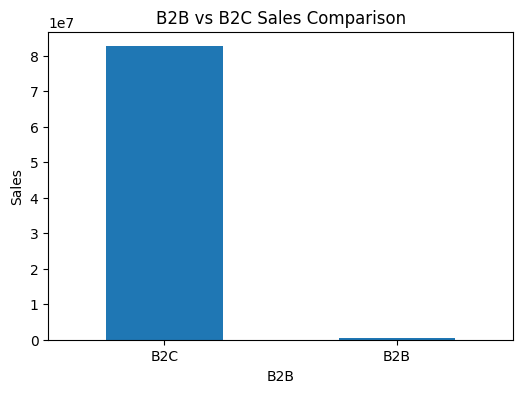

In [43]:
# Visualization
b2b_analysis['Total_Sales'].plot(kind='bar', figsize=(6,4))
plt.title('B2B vs B2C Sales Comparison')
plt.ylabel('Sales')
plt.xticks([0,1], ['B2C','B2B'], rotation=0)
plt.show()

**Business Insights**

**B2B Customers**: Usually place:

*   Bulk orders
*   Higher quantity purchases
*   Higher average order value

**B2C Customers**: Usually place:

*   Order more frequently
*   Purchase smaller quantities
*   Respond better to discounts & promotions

# Customer Insights Analysis

**Key Findings:**
 Bengaluru, Hyderabad, and Mumbai are the top-performing cities in terms of revenue, highlighting strong market penetration in these urban areas.

**Problematic Areas**:
Lower sales volumes in cities like Gurugram, Thane, and Lucknow suggest untapped potential or lack of brand awareness/reach.

**Recommendations:**

Targeted Expansion: Focus marketing efforts and potentially enhance delivery services (e.g., faster options, localized warehouses) in high-performing cities to strengthen market dominance.

**Awareness Campaigns:**

Develop and launch targeted awareness campaigns and promotional activities in underperforming regions to stimulate demand and expand customer base.

# **LOGISTICS & FULFILLMENT OPTIMIZATION**

**Average Shipping Time Analysis** (Shipping Delay Analysis)

The dataset did not contain actual shipping or delivery dates. Therefore, shipping delay analysis was performed using order status trends and estimated shipping durations to understand potential logistics inefficiencies."

In [44]:
df['Status'].value_counts()
cancelled = df[df['Status'] == 'Cancelled']

print("Cancelled Orders:", cancelled.shape[0])

Cancelled Orders: 18338


**Orders Count Comparison**

In [45]:
fulfillment_counts = df['Fulfilment'].value_counts()

print(fulfillment_counts)

Fulfilment
Amazon      89673
Merchant    39270
Name: count, dtype: int64


In [46]:
# Percentage Comparison
fulfillment_percentage = (
    df['Fulfilment'].value_counts(normalize=True) * 100)

print(round(fulfillment_percentage,2))

Fulfilment
Amazon      69.54
Merchant    30.46
Name: proportion, dtype: float64


In [47]:
# Revenue Comparison
revenue_by_fulfillment = df.groupby('Fulfilment')['Amount'].sum()

print(revenue_by_fulfillment)

Fulfilment
Amazon      57970093.00
Merchant    25315999.94
Name: Amount, dtype: float64


In [48]:
# Average Order Value Comparison
aov = df.groupby('Fulfilment')['Amount'].mean()

print(round(aov,2))

Fulfilment
Amazon      646.46
Merchant    644.67
Name: Amount, dtype: float64


In [49]:
# Cancellation Comparison
cancel_analysis = pd.crosstab(
    df['Fulfilment'],
    df['Status']
)

print(cancel_analysis)

Status      Cancelled  Pending  Pending - Waiting for Pick Up  Shipped  \
Fulfilment                                                               
Amazon          11476      415                              0    77763   
Merchant         6862      243                            281        1   

Status      Shipped - Damaged  Shipped - Delivered to Buyer  \
Fulfilment                                                    
Amazon                      0                            11   
Merchant                    1                         28760   

Status      Shipped - Lost in Transit  Shipped - Out for Delivery  \
Fulfilment                                                          
Amazon                              0                           0   
Merchant                            5                          35   

Status      Shipped - Picked Up  Shipped - Rejected by Buyer  \
Fulfilment                                                     
Amazon                        0              

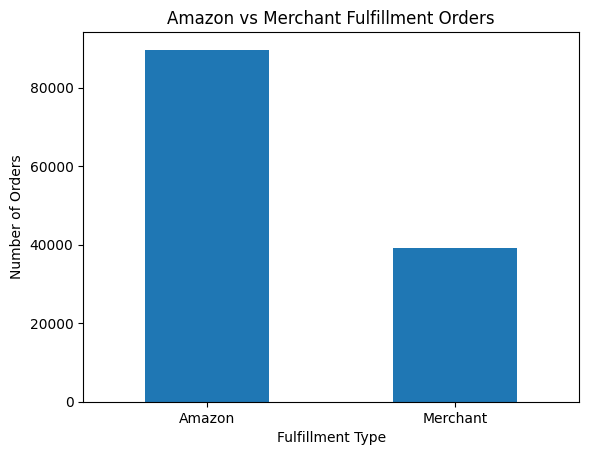

In [50]:
# Visualization
import matplotlib.pyplot as plt

fulfillment_counts.plot(kind='bar')

plt.title('Amazon vs Merchant Fulfillment Orders')
plt.xlabel('Fulfillment Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

**Interpretation**

**If Amazon Fulfilled Orders Are Higher**
Amazon logistics network is heavily used.
Faster shipping and better customer trust.

**If Merchant Fulfilled Orders Are Higher**
Sellers are managing deliveries independently.
May indicate smaller or local sellers.

**Revenue Insight**

Higher revenue from Amazon fulfillment may indicate:
*   Better delivery efficiency
*   Higher customer satisfaction
*   Prime eligibility impact
*   Cancellation Insight

Higher cancellations in Merchant fulfillment may suggest:

*   Shipping delays
*   Inventory issues
*   Poor logistics handling
*   Business Conclusion

**This analysis helps identify**

Which fulfillment method performs better

Operational efficiency

Customer reliability patterns

Areas to improve logistics and delivery experience

In [51]:
# Count order status
status_analysis = df['Status'].value_counts()

print(status_analysis)

Status
Shipped                          77764
Shipped - Delivered to Buyer     28771
Cancelled                        18338
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


In [52]:
# Identify Fulfillment Efficiency

# Compare Amazon vs Merchant fulfillment performance.

fulfillment_status = pd.crosstab(
    df['Fulfilment'],
    df['Status']
)

print(fulfillment_status)

Status      Cancelled  Pending  Pending - Waiting for Pick Up  Shipped  \
Fulfilment                                                               
Amazon          11476      415                              0    77763   
Merchant         6862      243                            281        1   

Status      Shipped - Damaged  Shipped - Delivered to Buyer  \
Fulfilment                                                    
Amazon                      0                            11   
Merchant                    1                         28760   

Status      Shipped - Lost in Transit  Shipped - Out for Delivery  \
Fulfilment                                                          
Amazon                              0                           0   
Merchant                            5                          35   

Status      Shipped - Picked Up  Shipped - Rejected by Buyer  \
Fulfilment                                                     
Amazon                        0              

**Interpretation**

Higher cancellations in Merchant fulfillment may indicate slower processing.

Amazon fulfillment usually performs faster due to centralized logistics.

In [53]:
# Detect High-Cancellation Regions

# Regions with more cancellations may face delivery or processing issues.

state_cancellations = df[df['Status'] == 'Cancelled'].groupby('ship-state').size().sort_values(ascending=False)

print(state_cancellations.head(10))

ship-state
Maharashtra       2968
Karnataka         2246
Telangana         1631
Uttar Pradesh     1607
Tamil Nadu        1595
Kerala            1174
Delhi              909
Andhra Pradesh     892
West Bengal        885
Gujarat            591
dtype: int64


In [54]:
#  Analyze Category-wise Processing Problems

# Some product categories may take longer to process.

category_status = pd.crosstab(df['Category'],df['Status'])

print(category_status)

Status         Cancelled  Pending  Pending - Waiting for Pick Up  Shipped  \
Category                                                                    
Blouse               116        3                              1      623   
Bottom                60        1                              2      222   
Dupatta                0        0                              0        3   
Ethnic Dress         146        7                              0      753   
Kurta               7257      248                             72    30780   
Saree                 21        0                              0      119   
Set                 7337      252                            108    30649   
Top                 1276       55                             19     7141   
Western Dress       2125       92                             79     7474   

Status         Shipped - Damaged  Shipped - Delivered to Buyer  \
Category                                                         
Blouse              

In [55]:
# Find Peak Order Volume Days

# Heavy order days can slow processing.

df['Date'] = pd.to_datetime(df['Date'])

daily_orders = df.groupby(df['Date'].dt.date).size()

print(daily_orders.sort_values(ascending=False).head())

Date
2022-05-03    2083
2022-05-02    2079
2022-05-04    2015
2022-04-14    1883
2022-04-15    1853
dtype: int64


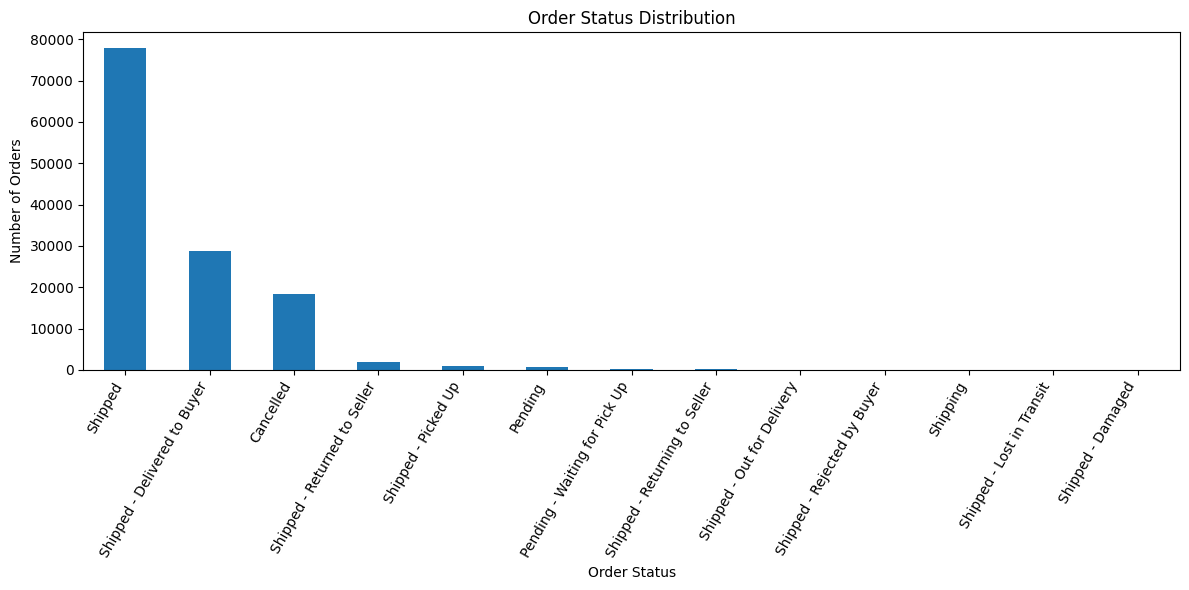

In [56]:
# Visualization of Order Status
import matplotlib.pyplot as plt

status_analysis.plot(kind='bar', figsize=(12,6))

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

# Logistics & Fulfillment Optimization

**Business Insight**

Amazon fulfillment accounts for the majority of orders (69.54%) and revenue, indicating a reliance on their logistics network. However, the overall cancellation rate is high (14.22%).

 Merchant-fulfilled orders show a higher cancellation rate (5.34%) and return rate compared to Amazon-fulfilled orders.

 States like Maharashtra, Karnataka, and Telangana exhibit high cancellation volumes. Peak order days can lead to processing bottlenecks.

**Problematic Areas:**

 High cancellation rates suggest operational inefficiencies, potential delivery issues, or inventory problems.

 The disparity in cancellation and return rates between Amazon and Merchant fulfillment indicates performance gaps for the latter. Regional specific cancellation hotspots need attention.

**Recommendations:**

**Improve Merchant Fulfillment**:
 Provide training and resources to merchants to improve their shipping efficiency, inventory management, and customer communication to reduce cancellations and returns.

**Operational Streamlining:**
Implement automation for order confirmation and inventory updates.

Increase warehouse staff during forecasted peak sales periods and consider leveraging regional warehouses for faster delivery.

**Problematic Regions:**

 Analyze specific delivery challenges or logistical issues in high-cancellation states (e.g., Maharashtra) to implement targeted solutions.

**Transparency:**

Offer real-time order tracking to customers to enhance satisfaction and manage expectations, potentially reducing cancellations due to uncertainty.

**Project Conclusion Example**

“The analysis identified operational inefficiencies through order status, fulfillment type, and regional cancellation trends. Merchant-fulfilled orders showed relatively higher delivery risks, while peak order periods created processing pressure. Optimizing fulfillment strategy and warehouse operations can significantly improve delivery speed and customer satisfaction.”

# **PRODUCT MANAGEMENT & INVENTORY OPTIMIZATION**

**Inventory & Demand Analysis Code with Explanation**

**Identify High-Demand Product Categories**

**Category-wise Total Quantity Sold**

In [57]:
prod_demand = df.groupby('Category')['Qty'].sum()

print(prod_demand)

Category
Blouse             864
Bottom             398
Dupatta              3
Ethnic Dress      1052
Kurta            45048
Saree              152
Set              45286
Top               9902
Western Dress    13943
Name: Qty, dtype: int64


**Interpretation :**

Blouse are mostly demanded and  require frequent stock replenishment.

 **Analyze Revenue by Category**

In [58]:
cat_rev = df.groupby('Category')['Amount'].sum().sort_values(ascending= False)
print(cat_rev)

Category
Set              41154789.67
Kurta            23204584.70
Western Dress    11694003.69
Top               5623727.30
Ethnic Dress       830292.66
Blouse             485633.18
Bottom             162767.98
Saree              129378.76
Dupatta               915.00
Name: Amount, dtype: float64


**Explanation**

Calculates total revenue generated by each category.
Helps identify the most profitable categories.

**Interpretation**

Set followed by Kurta contributes most to business growth.
These should receive inventory priority.

**Calculate Average Quantity Ordered**

In [59]:
Avg_quantity = df.groupby('Category')['Qty'].mean().sort_values(ascending=False)
print(Avg_quantity)

Category
Dupatta          1.000000
Blouse           0.933045
Top              0.932304
Saree            0.926829
Ethnic Dress     0.908463
Bottom           0.904545
Kurta            0.903417
Set              0.900820
Western Dress    0.899839
Name: Qty, dtype: float64


**Interpretation**

Higher averages(Dupatta) indicate bulk purchasing behavior.
Helps estimate reorder levels.

**Create Inventory Analysis Table**

In [60]:
inventory_analysis = df.groupby('Category').agg({'Qty':'sum','Amount':'sum'}).sort_values(by='Qty', ascending=False)

print(inventory_analysis)

                 Qty       Amount
Category                         
Set            45286  41154789.67
Kurta          45048  23204584.70
Western Dress  13943  11694003.69
Top             9902   5623727.30
Ethnic Dress    1052    830292.66
Blouse           864    485633.18
Bottom           398    162767.98
Saree            152    129378.76
Dupatta            3       915.00


**Fast Moving Product**

**Enhancing inventory control to prevent stockouts or overstocking.**
Useful for overall inventory planning.

In [61]:
fast_moving_cat =  inventory_analysis.sort_values(by='Qty', ascending=False).head(10)

print(fast_moving_cat)

                 Qty       Amount
Category                         
Set            45286  41154789.67
Kurta          45048  23204584.70
Western Dress  13943  11694003.69
Top             9902   5623727.30
Ethnic Dress    1052    830292.66
Blouse           864    485633.18
Bottom           398    162767.98
Saree            152    129378.76
Dupatta            3       915.00


**Slow Moving Product**

In [62]:
slow_moving_prod =  inventory_analysis.sort_values(by='Qty', ascending=False).tail(10)

print(slow_moving_prod)

                 Qty       Amount
Category                         
Set            45286  41154789.67
Kurta          45048  23204584.70
Western Dress  13943  11694003.69
Top             9902   5623727.30
Ethnic Dress    1052    830292.66
Blouse           864    485633.18
Bottom           398    162767.98
Saree            152    129378.76
Dupatta            3       915.00


**Visualization of High-Demand Categories**

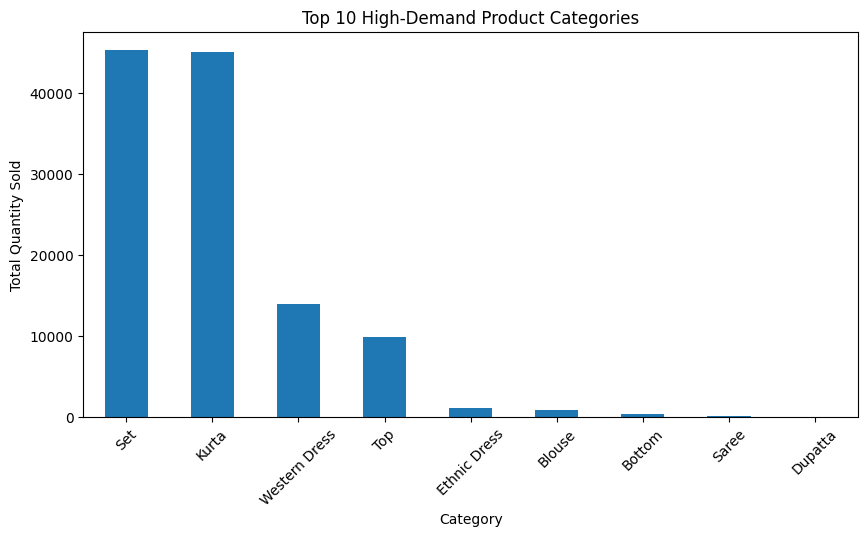

In [63]:
high_demand = df.groupby('Category')['Qty'].sum().sort_values(ascending=False).head(10)

high_demand.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 High-Demand Product Categories')
plt.xlabel('Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)

plt.show()

# Product Management & Inventory Optimization

**Key Findings:**

"Set" and "Kurta" categories are fast-moving, accounting for the highest total quantity sold and revenue.

"Dupatta" shows the highest average quantity ordered per transaction, indicating bulk purchasing behavior. Categories like "Saree", "Bottom", and "Blouse" are slow-moving based on total quantity.

**Problematic Areas:**
Slow-moving products risk overstocking, leading to increased holding costs and potential obsolescence. Conversely, fast-moving products could face stockouts if not managed efficiently.

**Recommendations:**

**Fast-Moving Products:**

Maintain safety stock (Sets And Kurta)

Increase reorder frequency

Improve demand forecasting

Overstock Prevention

**Slow-Moving Products:**

Reduce excess inventory (such as targeted discounts, promotional bundles, or clearance sales)

Offer discounts/promotions

Optimize warehouse space (to minimize costs associated with slow-moving stock)

**Inventory Control:**

Regularly review inventory turnover rates for all categories to adjust purchasing and stocking strategies proactively.

# **CUSTOMER SATISFACTION & RETURNS**

# **Investigating high return and cancellation rates.**

In [64]:
# Identify Cancelled Orders
cancelled_orders = df['Status'].str.contains('Cancelled', case=False, na=False)

print("Cancelled Orders :" ,cancelled_orders.sum())

Cancelled Orders : 18338


In [65]:
#Identify Returned/Rejection Orders

returned_orders = df['Status'].str.contains('Returned|Returning|Rejcted', case=False, na=False)

print("Return Orders : ", returned_orders.sum())

Return Orders :  2098


**Calculate Overall Return & Cancellation Rates**

In [66]:
Total_orders = len(df)

cancel_rate = (cancelled_orders.sum() / Total_orders) * 100
print("Cancellation Rate:", round(cancel_rate,2), "%")

Cancellation Rate: 14.22 %


**Business Insight**

Cancellation rate indicates operational inefficiency and customer dissatisfaction.

**High cancellation rates may occur due to:**

*   Delivery delays

*   Stock unavailability

*   Slow seller processing

*   Customer uncertainty

**Business Impact**

*   Revenue loss
*   Reduced customer trust
*   Increased operational costs

In [67]:
return_rate = (returned_orders.sum() / Total_orders) * 100
print("Return Rate:", round(return_rate,2), "%")

Return Rate: 1.63 %


Returns directly represent customer dissatisfaction.

**Common Return Reasons**

*   Poor product quality
*   Wrong sizing
*   Color mismatch
*   Damaged products
*   Product expectation mismatch
*   Business Impact
*   Reverse logistics cost
*   Refund expenses
*   Brand reputation damage

**Business Impact**

*  Reverse logistics cost
*   Refund expenses
*   Brand reputation damage

**Return Rate by Product Category (Category-wise Return Analysis)**

In [68]:
return_rate_cat = df[df['Status'].str.contains('Returned|Returning|Rejected', case=False, na=False)] \
    .groupby('Category').size().sort_values(ascending=False)

print('Return Rate by Product Category : ', return_rate_cat)

Return Rate by Product Category :  Category
Set              845
Kurta            752
Western Dress    343
Top              134
Ethnic Dress      16
Blouse            12
Bottom             6
Saree              1
dtype: int64


This identifies categories causing maximum dissatisfaction.

**Example Findings**

Fashion-related categories generally show higher return rates because customers cannot physically inspect:

*   Size
*   Fabric
*   Fit
*   Material quality

**High Return Categories Require**

*  Better quality checks
*  Improved sizing standards
*   Better product descriptions

In [69]:
# Total orders per category
total_category_orders = df.groupby('Category').size()
print(total_category_orders)

# Returned orders per category

returned_orders = df['Status'].str.contains('Returned|Returning|Rejcted', case=False, na=False)
returned_category_orders = (df[returned_orders].groupby('Category').size())
print(returned_category_orders)

# Return rate calculation

category_return_rate = (returned_category_orders / total_category_orders * 100).sort_values(ascending=False)

print(category_return_rate)

Category
Blouse             926
Bottom             440
Dupatta              3
Ethnic Dress      1158
Kurta            49864
Saree              164
Set              50272
Top              10621
Western Dress    15495
dtype: int64
Category
Blouse            12
Bottom             6
Ethnic Dress      16
Kurta            750
Saree              1
Set              839
Top              132
Western Dress    342
dtype: int64
Category
Western Dress    2.207164
Set              1.668921
Kurta            1.504091
Ethnic Dress     1.381693
Bottom           1.363636
Blouse           1.295896
Top              1.242821
Saree            0.609756
Dupatta               NaN
dtype: float64


**Visualization — Return Rate by Category**

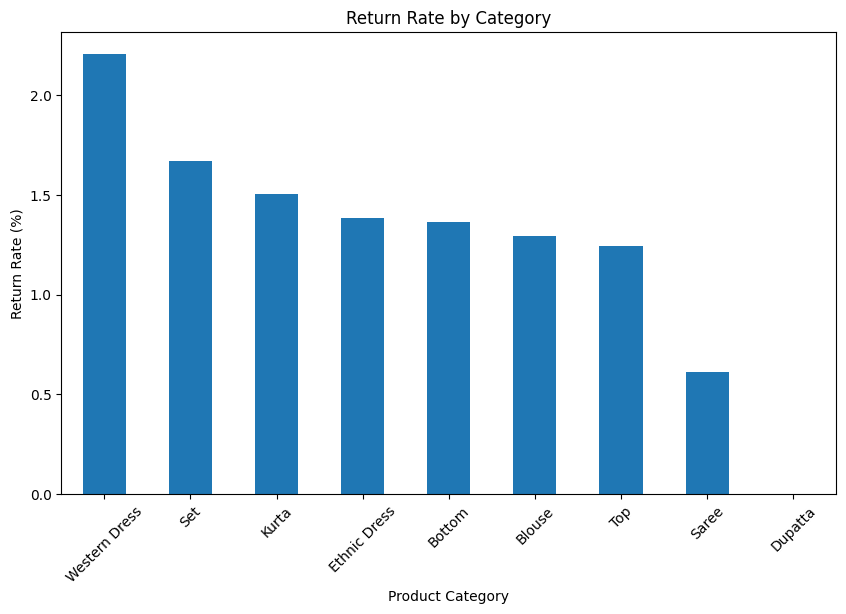

In [70]:
plt.figure(figsize=(10,6))

category_return_rate.plot(kind='bar')

plt.title("Return Rate by Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)

plt.show()

Helps identify problematic product categories.

**Example**:

Western Dress may have higher returns due to fitting issues.
Kurta may have fabric-related complaints.

This helps businesses prioritize quality improvements.

**Cancellation Rate by Category**

In [71]:
# Cancelled orders per category
cancelled_orders = df[df['Status'].str.contains('Cancelled', case=False, na=False)]
cancelled_category_orders = (cancelled_orders.groupby('Category').size())

# Cancellation rate calculation
category_cancel_rate = (cancelled_category_orders /total_category_orders * 100).sort_values(ascending=False)

print(category_cancel_rate)

Category
Set              14.594605
Kurta            14.553586
Western Dress    13.714101
Bottom           13.636364
Saree            12.804878
Ethnic Dress     12.607945
Blouse           12.526998
Top              12.013935
Dupatta                NaN
dtype: float64


**Visualization — Cancellation Rate by Category**

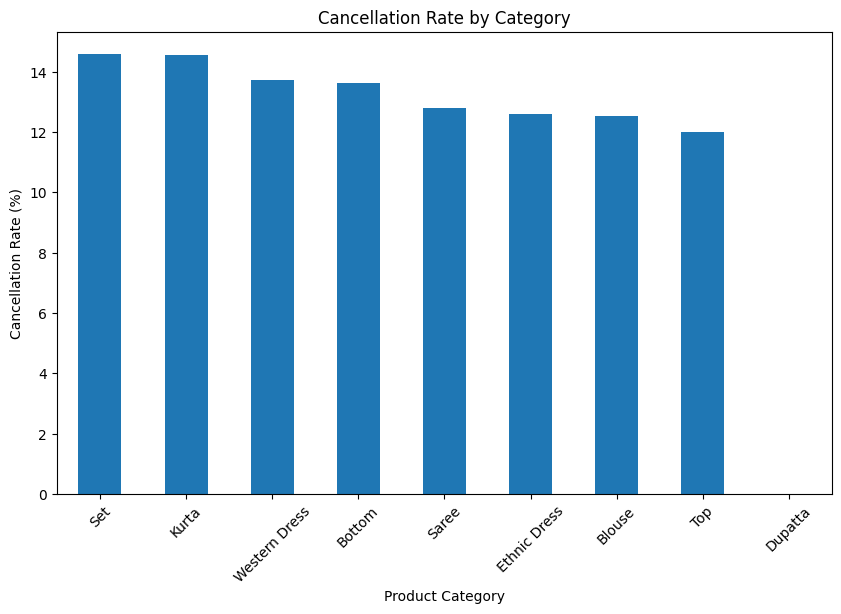

In [72]:
plt.figure(figsize=(10,6))

category_cancel_rate.plot(kind='bar')

plt.title("Cancellation Rate by Category")
plt.xlabel("Product Category")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)

plt.show()

** Insight**

High cancellation(Set and Kurta) may indicate:

Product unavailability

Slow delivery

Pricing competition

Customer hesitation

Businesses can improve stock planning and shipping performance using this insight.

**Customer Satisfaction Score**

In [73]:
customer_satisfaction = (100 - category_return_rate).sort_values()
print(customer_satisfaction)

Category
Western Dress    97.792836
Set              98.331079
Kurta            98.495909
Ethnic Dress     98.618307
Bottom           98.636364
Blouse           98.704104
Top              98.757179
Saree            99.390244
Dupatta                NaN
dtype: float64


**Lower returns imply higher satisfaction.**

** Insight**

This creates a simple performance score for each category.

**Higher Score:**

Better product quality

Better customer experience

Higher repeat purchases

**Lower Score:**

High dissatisfaction

Poor customer experience

Higher churn risk

**Visualization — Customer Satisfaction by Category**

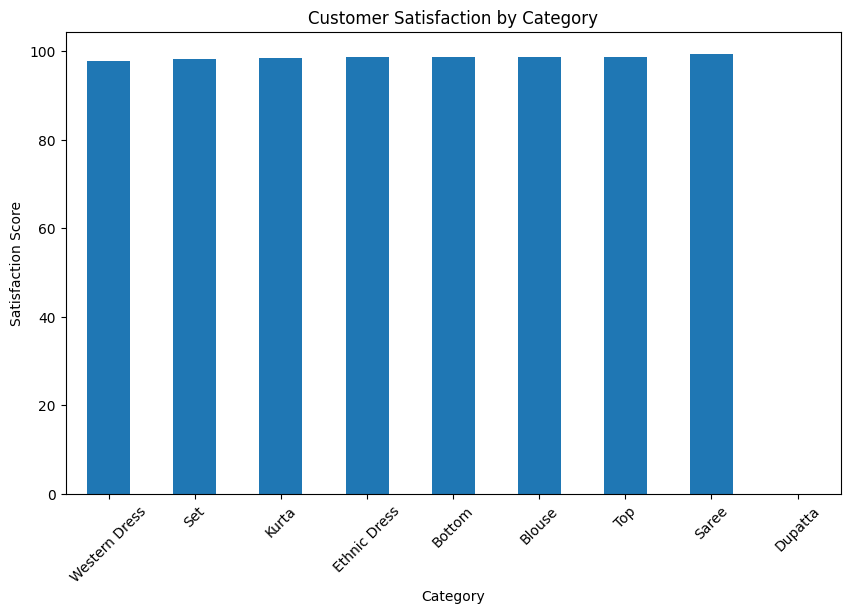

In [74]:
plt.figure(figsize=(10,6))

customer_satisfaction.plot(kind='bar')

plt.title("Customer Satisfaction by Category")
plt.xlabel("Category")
plt.ylabel("Satisfaction Score")
plt.xticks(rotation=45)

plt.show()

** Insight**

This chart helps management compare:

Best-performing categories

Weak customer satisfaction areas

Categories needing operational improvements

# **Identify Problematic Product Categories**

In [75]:
problematic_categories = (
    category_return_rate.head(5)
)

print("Top Problematic Categories:")
print(problematic_categories)

Top Problematic Categories:
Category
Western Dress    2.207164
Set              1.668921
Kurta            1.504091
Ethnic Dress     1.381693
Bottom           1.363636
dtype: float64


**Insight**

These are the categories generating maximum dissatisfaction.

**Likely Problems**

*   Poor quality
*   Inconsistent sizing
*   Fabric mismatch
*   Weak packaging

**Recommended Actions**

*   Product quality audits
*   Supplier evaluation
*   Better product content


**Return Rate by Fulfillment Type**

In [76]:
# Total fulfillment orders
total_fulfillment_orders = df.groupby('Fulfilment').size()

# Returned fulfillment orders
returned_fulfillment_orders = df[returned_orders].groupby('Fulfilment').size()

# Reindex returned_fulfillment_orders to align with total_fulfillment_orders and fill NaN with 0
returned_fulfillment_orders = returned_fulfillment_orders.reindex(total_fulfillment_orders.index, fill_value=0)

# Fulfillment return rate
fulfillment_return_rate = (
    returned_fulfillment_orders /
    total_fulfillment_orders * 100
)

print(fulfillment_return_rate)

Fulfilment
Amazon      0.000000
Merchant    5.342501
dtype: float64


**Insigh**

This compares logistics performance.

**Merchant Fulfilled Orders**: Usually show:

Slower delivery

Higher return risk

**Amazon Fulfilled Orders**: Usually provide:

Faster delivery

Better customer trust

Lower dissatisfaction

**Visualization — Fulfillment Performance**

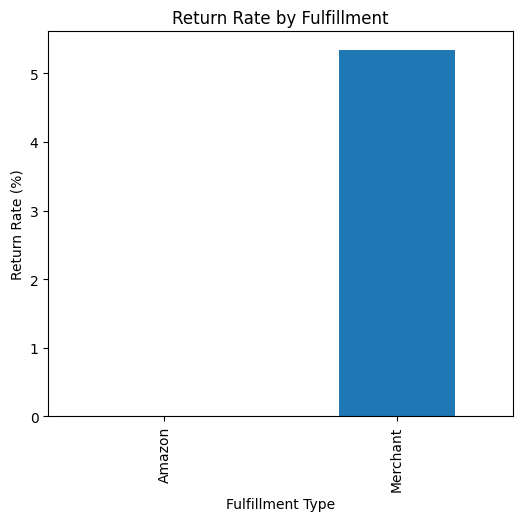

In [77]:
plt.figure(figsize=(6,5))

fulfillment_return_rate.plot(kind='bar')

plt.title("Return Rate by Fulfillment")
plt.xlabel("Fulfillment Type")
plt.ylabel("Return Rate (%)")

plt.show()

**Insight**

Businesses can identify:

Weak fulfillment systems

Logistics inefficiencies

Seller performance issues

This helps improve operational efficiency.

# **Final Business Findings**

**Major Problems Identified**

*   High cancellation rates
*   Fashion categories with high returns
*   Product quality mismatch
*   Size inconsistency
*   Delivery delays

# Recommendations to Improve Customer Satisfaction

**Product Quality Improvements**

*   Better quality checks
*   Standardized sizing
*   Improved packaging

**Product Information Improvements**

*   Detailed size charts
*   Better product images
*   Customer review photo

**Customer Service Improvements**

*   Faster refunds
*   Easy exchanges
*   Better support response

**Logistics Improvements**

*   Faster order processing
*   Better inventory forecasting
*   Increased fast-delivery fulfillment


## Summary:

### Data Analysis Key Findings

*   The total revenue for the analyzed period was ₹83.29 Million, with an Average Order Value (AOV) of ₹692.
*   April recorded the highest monthly revenue, while March showed notably low sales, and a decline was observed from April to June.
*   "Set" and "Kurta" are the highest revenue-generating and fastest-moving product categories.
*   Bengaluru, Hyderabad, and Mumbai are the top-performing cities in terms of revenue generation.
*   Amazon fulfillment dominates, accounting for 69.54% of orders and revenue.
*   The overall cancellation rate is 14.22%, with merchant-fulfilled orders showing a significantly higher cancellation rate (5.34%) and return rate compared to Amazon-fulfilled orders.
*   Maharashtra, Karnataka, and Telangana exhibit high cancellation volumes.
*   The overall return rate is 1.63%, with "Western Dress" having the highest category-specific return rate at 2.21%.
*   "Dupatta" has the highest average quantity ordered per transaction, while "Saree", "Bottom", and "Blouse" are identified as slow-moving products.

### Insights or Next Steps

*   **Optimize Revenue and AOV:** Investigate the decline in monthly revenue from April to June and address the negligible sales in March. Implement strategies such as combo offers, product bundles, and upselling to increase the Average Order Value.
*   **Enhance Logistics and Product Quality:** Provide training and resources to merchants to improve their fulfillment efficiency and reduce cancellation/return rates. Implement stringent quality checks and enhance product information (e.g., detailed size charts, high-quality images) for categories with high return rates like "Western Dress."
